In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import sys
sys.path.append('../')

from minilearn.neural_network import ANN as MiniANN
from minilearn.metrics import accuracy_score as mini_accuracy

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.svm import SVC

#load saved data
train_df = pd.read_csv('../data/train_features.csv')
test_df = pd.read_csv('../data/test_features.csv')

#seperate featuer and labels
feature_col = [col for col in train_df.columns if col != 'emotion']

X_train = train_df[feature_col].values
y_train = train_df['emotion'].values

X_test = test_df[feature_col].values
y_test = test_df['emotion'].values

#fix featul label space issue
y_train = np.array([label.strip() for label in y_train])
y_test = np.array([label.strip() for label in y_test])

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Classes: {np.unique(y_train)}")

Training set: (1961, 112)
Test set: (491, 112)
Classes: ['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']


In [ ]:
#Train mini ANN
print("Training MiniLearn ANN")
mini_ann = MiniANN(hidden_size=128, learning_rate=0.01, n_iterations=1000)
mini_ann.fit(X_train, y_train)

#Evalaute
mini_ann_preds = mini_ann.predict(X_test)
mini_ann_acc = accuracy_score(y_test, mini_ann_preds)
mini_ann_Macc = mini_accuracy(y_test, mini_ann_preds)
print(f'\nMiniLearn ANN Test Accuracy: {mini_ann_acc:.4f}')
print(f'\nMiniLearn ANN Test MiniAccuracy: {mini_ann_Macc:.4f}')


Training MiniLearn ANN
Iteration 100/1000 | Loss: 2.0597
Iteration 200/1000 | Loss: 2.0371
Iteration 300/1000 | Loss: 2.0018
Iteration 400/1000 | Loss: 1.9427
Iteration 500/1000 | Loss: 1.8625
Iteration 600/1000 | Loss: 1.7871
Iteration 700/1000 | Loss: 1.7286
Iteration 800/1000 | Loss: 1.6813
Iteration 900/1000 | Loss: 1.6399
Iteration 1000/1000 | Loss: 1.6017

MiniLearn ANN Test Accuracy: 0.3910

MiniLearn ANN Test MiniAccuracy: 0.3910


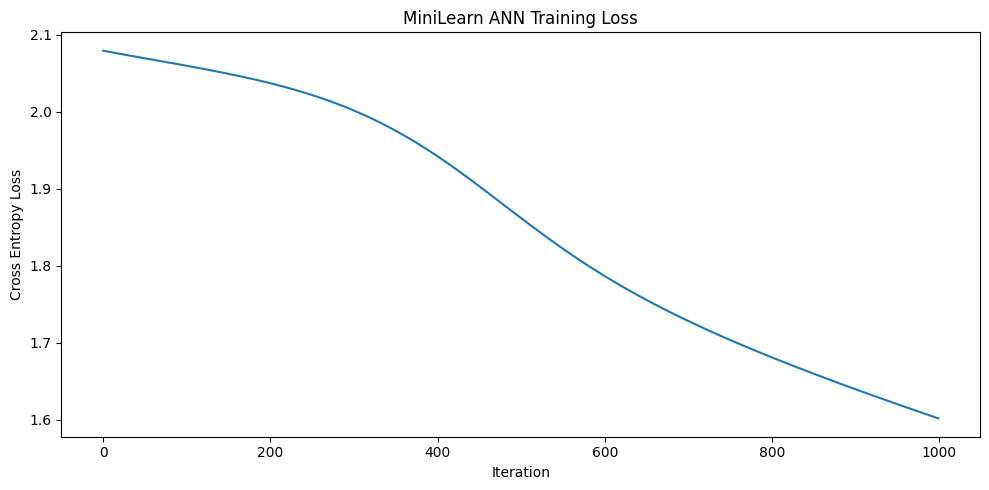

In [3]:
#plotting this ^
plt.figure(figsize=(10,5))
plt.plot(mini_ann.loss_history)
plt.title('MiniLearn ANN Training Loss')
plt.xlabel('Iteration')
plt.ylabel('Cross Entropy Loss')
plt.tight_layout()
plt.show()


In [6]:
#Try training with more iterations see if accuracy increases
print('Training MiniLearn ANN 2000 Iterations')
mini_ann2 = MiniANN(hidden_size=256, learning_rate=0.01, n_iterations=2000)
mini_ann2.fit(X_train, y_train)

mini_ann2_preds = mini_ann2.predict(X_test)
mini_ann2_acc = mini_accuracy(y_test, mini_ann2_preds)
print(f'\nMiniLearn ANN 2000 iter Test Accuracy: {mini_ann2_acc:.4f}')


Training MiniLearn ANN 2000 Iterations
Iteration 100/2000 | Loss: 2.0476
Iteration 200/2000 | Loss: 2.0090
Iteration 300/2000 | Loss: 1.9488
Iteration 400/2000 | Loss: 1.8659
Iteration 500/2000 | Loss: 1.7851
Iteration 600/2000 | Loss: 1.7219
Iteration 700/2000 | Loss: 1.6709
Iteration 800/2000 | Loss: 1.6260
Iteration 900/2000 | Loss: 1.5844
Iteration 1000/2000 | Loss: 1.5444
Iteration 1100/2000 | Loss: 1.5053
Iteration 1200/2000 | Loss: 1.4664
Iteration 1300/2000 | Loss: 1.4278
Iteration 1400/2000 | Loss: 1.3895
Iteration 1500/2000 | Loss: 1.3515
Iteration 1600/2000 | Loss: 1.3141
Iteration 1700/2000 | Loss: 1.2774
Iteration 1800/2000 | Loss: 1.2414
Iteration 1900/2000 | Loss: 1.2063
Iteration 2000/2000 | Loss: 1.1721

MiniLearn ANN 2000 iter Test Accuracy: 0.5580


In [7]:
#Building PyTorch model
classes = np.unique(y_train)
label_to_idx = {label: idx for idx, label in enumerate(classes)}

y_train_encoded = np.array([label_to_idx[label] for label in y_train])
y_test_encoded = np.array([label_to_idx[label] for label in y_test])

#convert to pytorch tensors
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.LongTensor(y_train_encoded)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.LongTensor(y_test_encoded)

#create DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset,batch_size=32, shuffle=True)

print(f"Training batches {len(train_loader)}")
print(f"Classes: {classes}")


Training batches 62
Classes: ['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']


In [9]:
class EmotionNN(nn.Module):
    def __init__(self, input_size, hidden_size, n_classes):
        super(EmotionNN, self).__init__()

        #define layers
        self.network = nn.Sequential(nn.Linear(input_size, 256), nn.ReLU(), nn.Dropout(0.3), nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.3), nn.Linear(128,64), nn.ReLU(), nn.Linear(64, n_classes))

    def forward(self,x):
        #forward pass through the network
        return self.network(x)

#initializing model
input_size = X_train.shape[1]
n_classes = len(classes)
model = EmotionNN(input_size=input_size, hidden_size=256, n_classes=n_classes)

#loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters())}')


EmotionNN(
  (network): Sequential(
    (0): Linear(in_features=112, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Linear(in_features=64, out_features=8, bias=True)
  )
)

Total parameters: 70600


In [11]:
#train pytorch model
n_epochs = 100
train_losses = []
train_accs = []

for epoch in range(n_epochs):
    model.train()
    epoch_loss = 0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:
        #forward pass
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        #backward pass
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        _, predicted = torch.max(outputs,1)
        total += y_batch.size(0)
        correct +=(predicted == y_batch).sum().item()

    avg_loss = epoch_loss / len(train_loader)
    avg_acc = correct / total
    train_losses.append(avg_loss)
    train_accs.append(avg_acc)

    if (epoch+1) % 10 == 0:
        print(f'Epoch {epoch+1}/{n_epochs} | Loss: {avg_loss:.4f} | Accuracy: {avg_acc:.4f}')
#evalute on test set

model.eval()
with torch.no_grad():
    outputs = model(X_test_tensor)
    _, predicted = torch.max(outputs,1)
    pytorch_preds = predicted.numpy()
    pytorch_acc = accuracy_score(y_test_encoded, pytorch_preds)

print(f"\nPytorch Neural Network Test Accuracy: {pytorch_acc:.4f}")



Epoch 10/100 | Loss: 0.0771 | Accuracy: 0.9730
Epoch 20/100 | Loss: 0.0700 | Accuracy: 0.9765
Epoch 30/100 | Loss: 0.0555 | Accuracy: 0.9771
Epoch 40/100 | Loss: 0.0536 | Accuracy: 0.9827
Epoch 50/100 | Loss: 0.0613 | Accuracy: 0.9811
Epoch 60/100 | Loss: 0.0593 | Accuracy: 0.9811
Epoch 70/100 | Loss: 0.0609 | Accuracy: 0.9801
Epoch 80/100 | Loss: 0.0426 | Accuracy: 0.9857
Epoch 90/100 | Loss: 0.0568 | Accuracy: 0.9816
Epoch 100/100 | Loss: 0.0480 | Accuracy: 0.9878

Pytorch Neural Network Test Accuracy: 0.7699
